1km Buffer Study

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [22]:


base_path = "/content/drive/MyDrive/Classic UHI"

modis_file = os.path.join(
    base_path,
    "MODIS_Day_Night_LST_1km_Reference_2020_2024.csv"
)

landsat_file = os.path.join(
    base_path,
    "Classic_UHI_LST_NDVI_1km_Reference_2020_2024.csv"
)


modis = pd.read_csv(modis_file)
landsat = pd.read_csv(landsat_file)

print("MODIS columns:", modis.columns.tolist())
print("Landsat columns:", landsat.columns.tolist())


modis_pivot = modis.pivot_table(
    index=["year", "month"],
    columns="region",
    values=["mean_LST_Day_C", "mean_LST_Night_C"]
).reset_index()

modis_pivot.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in modis_pivot.columns
]

modis_pivot["Daytime_SUHI_C"] = (
    modis_pivot["mean_LST_Day_C_Urban"]
    - modis_pivot["mean_LST_Day_C_Reference_1km"]
)

modis_pivot["Nighttime_SUHI_C"] = (
    modis_pivot["mean_LST_Night_C_Urban"]
    - modis_pivot["mean_LST_Night_C_Reference_1km"]
)



landsat_urban = landsat[landsat["region"] == "Urban"].copy()



yearly_modis = modis_pivot.groupby("year").agg({
    "mean_LST_Day_C_Urban": "mean",
    "Daytime_SUHI_C": "mean",
    "mean_LST_Night_C_Urban": "mean",
    "Nighttime_SUHI_C": "mean"
}).reset_index()

yearly_ndvi = landsat_urban.groupby("year").agg({
    "mean_NDVI": "mean"
}).reset_index()

yearly_table = yearly_modis.merge(yearly_ndvi, on="year", how="left")

# ------------------------------------------------------------
# Step 6: Format like YRD table
# ------------------------------------------------------------

final_table = pd.DataFrame({
    "Parameter": [
        "Daytime LST (°C)",
        "Daytime SUHI (°C)",
        "Nighttime LST (°C)",
        "Nighttime SUHI (°C)",
        "NDVI"
    ]
})

for year in range(2020, 2025):
    row = yearly_table[yearly_table["year"] == year]
    final_table[str(year)] = [
        row["mean_LST_Day_C_Urban"].values[0],
        row["Daytime_SUHI_C"].values[0],
        row["mean_LST_Night_C_Urban"].values[0],
        row["Nighttime_SUHI_C"].values[0],
        row["mean_NDVI"].values[0]
    ]

final_table["Average"] = final_table[[str(y) for y in range(2020, 2025)]].mean(axis=1)

# Round values
final_table = final_table.round(2)

final_table

MODIS columns: ['system:index', 'mean_LST_Day_C', 'mean_LST_Night_C', 'modis_image_count', 'month', 'region', 'year', '.geo']
Landsat columns: ['system:index', 'landsat_image_count', 'mean_LST_C', 'mean_NDVI', 'month', 'region', 'year', '.geo']


,Parameter,2020,2021,2022,2023,2024,Average
0,Daytime LST (°C),32.10,31.72,32.03,31.78,31.61,31.85
1,Daytime SUHI (°C),0.66,0.73,0.73,0.92,0.53,0.71
2,Nighttime LST (°C),20.03,20.36,21.04,20.43,21.02,20.58
3,Nighttime SUHI (°C),2.06,2.03,2.04,2.26,2.15,2.11
4,NDVI,0.30,0.29,0.31,0.31,0.30,0.30


Deviation from 2020--2024 average:


,Parameter,2020,2021,2022,2023,2024
0,Daytime LST (°C),0.25,-0.13,0.18,-0.07,-0.24
1,Daytime SUHI (°C),-0.05,0.02,0.02,0.21,-0.18
2,Nighttime LST (°C),-0.55,-0.22,0.46,-0.15,0.44
3,Nighttime SUHI (°C),-0.05,-0.08,-0.07,0.15,0.04
4,NDVI,0.00,-0.01,0.01,0.01,0.00


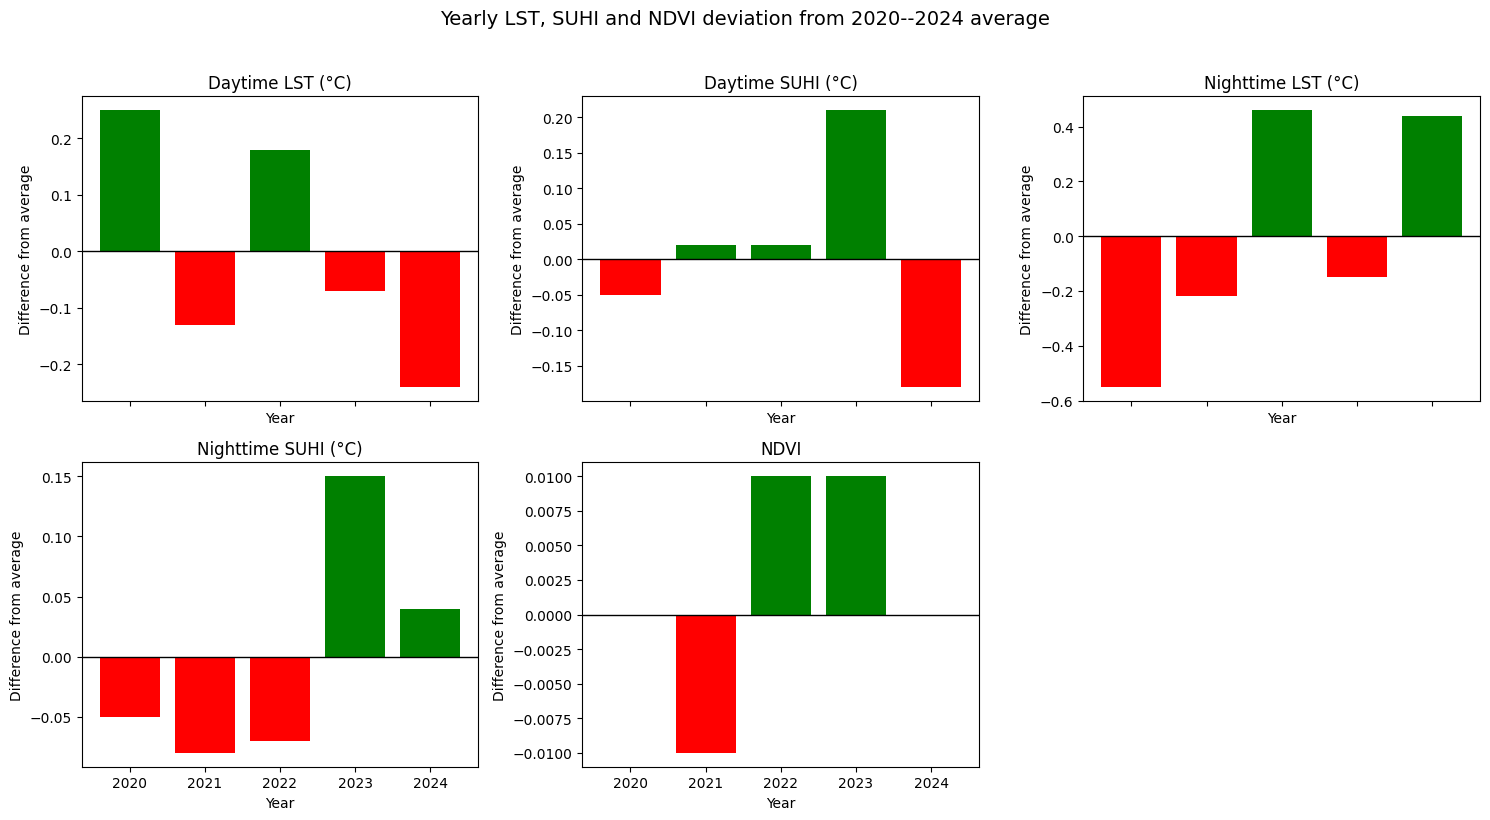

In [23]:


# Use final_table created in Block 1
year_cols = ["2020", "2021", "2022", "2023", "2024"]

deviation_table = final_table.copy()

for year in year_cols:
    deviation_table[year] = deviation_table[year] - deviation_table["Average"]

deviation_table = deviation_table[["Parameter"] + year_cols]

print("Deviation from 2020--2024 average:")
display(deviation_table.round(2))


n_params = len(deviation_table)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    sharex=True
)

axes = axes.flatten()

for i, (_, row) in enumerate(deviation_table.iterrows()):
    parameter = row["Parameter"]
    values = row[year_cols].astype(float).values

    colors = ["green" if v >= 0 else "red" for v in values]

    axes[i].bar(year_cols, values, color=colors)
    axes[i].axhline(0, color="black", linewidth=1)
    axes[i].set_title(parameter)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Difference from average")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Yearly LST, SUHI and NDVI deviation from 2020--2024 average",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

In [24]:


base_path = "/content/drive/MyDrive/Classic UHI"

modis_file = os.path.join(
    base_path,
    "MODIS_Day_Night_LST_1km_Reference_2020_2024.csv"
)

landsat_file = os.path.join(
    base_path,
    "Classic_UHI_LST_NDVI_1km_Reference_2020_2024.csv"
)



modis = pd.read_csv(modis_file)
landsat = pd.read_csv(landsat_file)

print(modis.head())
print(landsat.head())

  system:index  mean_LST_Day_C  mean_LST_Night_C  modis_image_count  month  \
0        0_0_0       19.626821          9.842689                  8    1.0   
1        0_0_1       18.954045          7.924584                  8    1.0   
2        0_1_0       26.103597         14.150439                  8    2.0   
3        0_1_1       24.568095         13.223126                  8    2.0   
4        0_2_0       31.270941         17.355039                  8    3.0   

          region    year                                    .geo  
0          Urban  2020.0  {"type":"MultiPoint","coordinates":[]}  
1  Reference_1km  2020.0  {"type":"MultiPoint","coordinates":[]}  
2          Urban  2020.0  {"type":"MultiPoint","coordinates":[]}  
3  Reference_1km  2020.0  {"type":"MultiPoint","coordinates":[]}  
4          Urban  2020.0  {"type":"MultiPoint","coordinates":[]}  
  system:index  landsat_image_count  mean_LST_C  mean_NDVI  month  \
0        0_0_0                    5   19.291874   0.260074  

In [25]:


modis_pivot = modis.pivot_table(
    index=["year", "month"],
    columns="region",
    values=["mean_LST_Day_C", "mean_LST_Night_C"]
).reset_index()

modis_pivot.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in modis_pivot.columns
]

modis_pivot["Daytime_SUHI_C"] = (
    modis_pivot["mean_LST_Day_C_Urban"]
    - modis_pivot["mean_LST_Day_C_Reference_1km"]
)

modis_pivot["Nighttime_SUHI_C"] = (
    modis_pivot["mean_LST_Night_C_Urban"]
    - modis_pivot["mean_LST_Night_C_Reference_1km"]
)



landsat_urban = landsat[landsat["region"] == "Urban"].copy()

monthly_ndvi = landsat_urban.groupby("month", as_index=False)["mean_NDVI"].mean()



monthly_modis = modis_pivot.groupby("month", as_index=False).agg({
    "mean_LST_Day_C_Urban": "mean",
    "Daytime_SUHI_C": "mean",
    "mean_LST_Night_C_Urban": "mean",
    "Nighttime_SUHI_C": "mean"
})

monthly_plot = monthly_modis.merge(monthly_ndvi, on="month", how="left")

monthly_plot

,month,mean_LST_Day_C_Urban,Daytime_SUHI_C,mean_LST_Night_C_Urban,Nighttime_SUHI_C,mean_NDVI
0,1.0,19.794788,0.672309,9.669590,1.671854,0.256424
1,2.0,26.506561,1.473991,14.460019,1.813051,0.254354
2,3.0,33.547409,1.538656,19.701321,2.840582,0.262649
3,4.0,39.013396,-0.050258,23.804830,3.097826,0.258313
4,5.0,39.661765,-0.132575,25.851586,2.708993,0.252213
5,6.0,38.555259,0.192600,27.016778,1.635273,0.280268
6,7.0,36.277468,1.334084,26.444512,0.938630,0.368307
7,8.0,33.389430,1.357889,25.431978,1.501874,0.412636
8,9.0,34.220814,1.290241,25.442583,1.458488,0.406817
9,10.0,32.396114,0.525001,21.240447,3.352783,0.331169


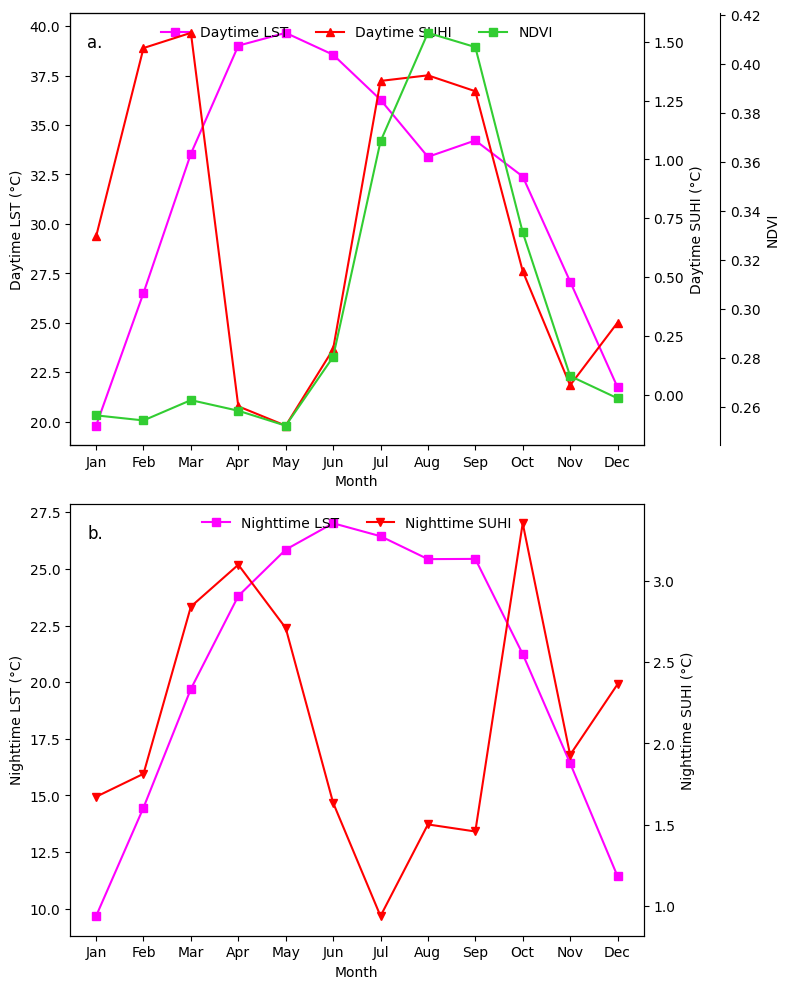

Saved figure: /content/drive/MyDrive/Classic UHI/Monthly_LST_SUHI_NDVI_Delhi_2020_2024.png


In [26]:


month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

x = monthly_plot["month"]

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=False)



ax1 = axes[0]

line1 = ax1.plot(
    x,
    monthly_plot["mean_LST_Day_C_Urban"],
    marker="s",
    color="magenta",
    label="Daytime LST"
)

ax1.set_ylabel("Daytime LST (°C)")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.set_xlabel("Month")

ax2 = ax1.twinx()

line2 = ax2.plot(
    x,
    monthly_plot["Daytime_SUHI_C"],
    marker="^",
    color="red",
    label="Daytime SUHI"
)

ax2.set_ylabel("Daytime SUHI (°C)")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 55))

line3 = ax3.plot(
    x,
    monthly_plot["mean_NDVI"],
    marker="s",
    color="limegreen",
    label="NDVI"
)

ax3.set_ylabel("NDVI")

# Combined legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", ncol=3, frameon=False)

ax1.text(0.03, 0.92, "a.", transform=ax1.transAxes, fontsize=12)



ax4 = axes[1]

line4 = ax4.plot(
    x,
    monthly_plot["mean_LST_Night_C_Urban"],
    marker="s",
    color="magenta",
    label="Nighttime LST"
)

ax4.set_ylabel("Nighttime LST (°C)")
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_labels)
ax4.set_xlabel("Month")

ax5 = ax4.twinx()

line5 = ax5.plot(
    x,
    monthly_plot["Nighttime_SUHI_C"],
    marker="v",
    color="red",
    label="Nighttime SUHI"
)

ax5.set_ylabel("Nighttime SUHI (°C)")

lines = line4 + line5
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc="upper center", ncol=2, frameon=False)

ax4.text(0.03, 0.92, "b.", transform=ax4.transAxes, fontsize=12)

plt.tight_layout()

output_path = os.path.join(
    base_path,
    "Monthly_LST_SUHI_NDVI_Delhi_2020_2024.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

,month,Daytime_SUHI_C,Nighttime_SUHI_C,Suburban_NDVI
0,1.0,0.672,1.672,0.536
1,2.0,1.474,1.813,0.558
2,3.0,1.539,2.841,0.505
3,4.0,-0.050,3.098,0.301
4,5.0,-0.133,2.709,0.273
5,6.0,0.193,1.635,0.349
6,7.0,1.334,0.939,0.506
7,8.0,1.358,1.502,0.604
8,9.0,1.290,1.458,0.594
9,10.0,0.525,3.353,0.451


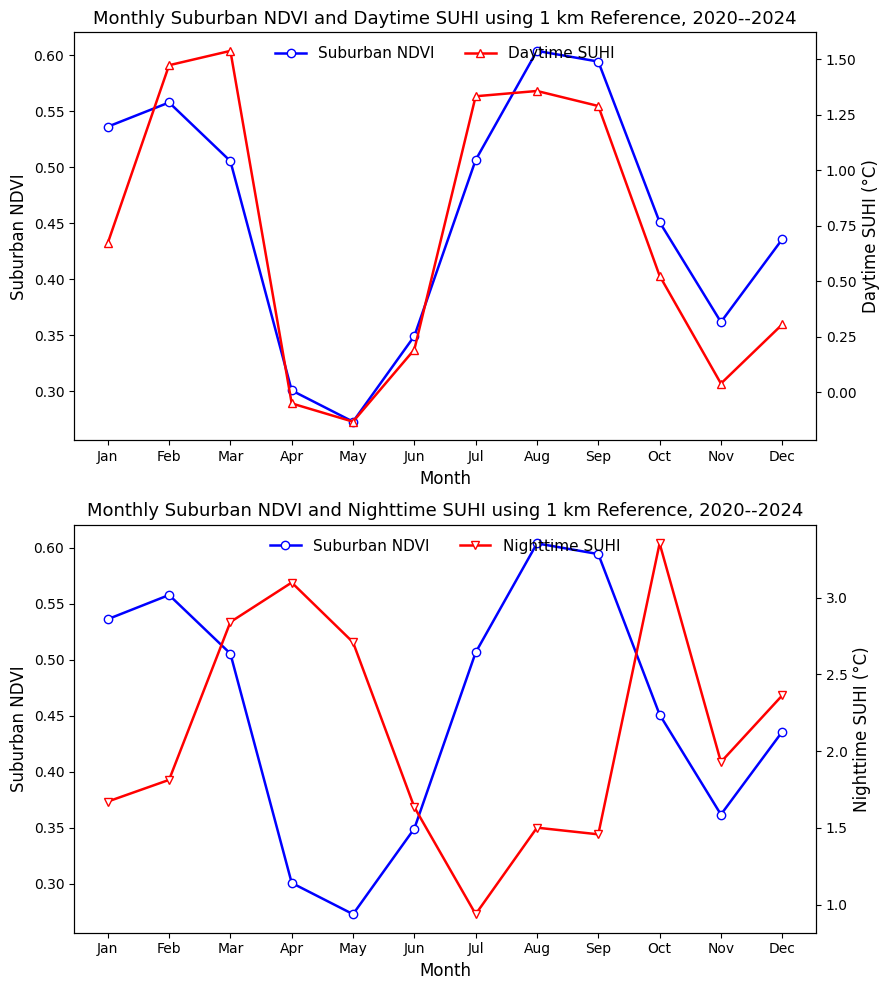

In [27]:


base_path = "/content/drive/MyDrive/Classic UHI"

modis_file = os.path.join(
    base_path,
    "MODIS_Day_Night_LST_1km_Reference_2020_2024.csv"
)

landsat_file = os.path.join(
    base_path,
    "Classic_UHI_LST_NDVI_1km_Reference_2020_2024.csv"
)



modis = pd.read_csv(modis_file)
landsat = pd.read_csv(landsat_file)


modis = modis.drop(columns=[col for col in ["system:index", ".geo"] if col in modis.columns], errors="ignore")
landsat = landsat.drop(columns=[col for col in ["system:index", ".geo"] if col in landsat.columns], errors="ignore")


for col in ["year", "month", "mean_LST_Day_C", "mean_LST_Night_C"]:
    if col in modis.columns:
        modis[col] = pd.to_numeric(modis[col], errors="coerce")

for col in ["year", "month", "mean_NDVI"]:
    if col in landsat.columns:
        landsat[col] = pd.to_numeric(landsat[col], errors="coerce")



modis_pivot = modis.pivot_table(
    index=["year", "month"],
    columns="region",
    values=["mean_LST_Day_C", "mean_LST_Night_C"]
).reset_index()

modis_pivot.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in modis_pivot.columns
]

modis_pivot["Daytime_SUHI_C"] = (
    modis_pivot["mean_LST_Day_C_Urban"]
    - modis_pivot["mean_LST_Day_C_Reference_1km"]
)

modis_pivot["Nighttime_SUHI_C"] = (
    modis_pivot["mean_LST_Night_C_Urban"]
    - modis_pivot["mean_LST_Night_C_Reference_1km"]
)

monthly_modis = modis_pivot.groupby("month", as_index=False).agg({
    "Daytime_SUHI_C": "mean",
    "Nighttime_SUHI_C": "mean"
})



suburban_ndvi = (
    landsat[landsat["region"] == "Reference_1km"]
    .groupby("month", as_index=False)["mean_NDVI"]
    .mean()
    .rename(columns={"mean_NDVI": "Suburban_NDVI"})
)



monthly_suhi_ndvi = monthly_modis.merge(suburban_ndvi, on="month", how="left")

display(monthly_suhi_ndvi.round(3))



month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(2, 1, figsize=(9, 10), sharex=False)


ax1 = axes[0]

line1 = ax1.plot(
    monthly_suhi_ndvi["month"],
    monthly_suhi_ndvi["Suburban_NDVI"],
    marker="o",
    color="blue",
    linewidth=1.8,
    markerfacecolor="white",
    label="Suburban NDVI"
)

ax1.set_ylabel("Suburban NDVI", fontsize=12)
ax1.set_xlabel("Month", fontsize=12)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)

ax2 = ax1.twinx()

line2 = ax2.plot(
    monthly_suhi_ndvi["month"],
    monthly_suhi_ndvi["Daytime_SUHI_C"],
    marker="^",
    color="red",
    linewidth=1.8,
    markerfacecolor="white",
    label="Daytime SUHI"
)

ax2.set_ylabel("Daytime SUHI (°C)", fontsize=12)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", ncol=2, frameon=False, fontsize=11)

ax1.set_title("Monthly Suburban NDVI and Daytime SUHI using 1 km Reference, 2020--2024", fontsize=13)


ax3 = axes[1]

line3 = ax3.plot(
    monthly_suhi_ndvi["month"],
    monthly_suhi_ndvi["Suburban_NDVI"],
    marker="o",
    color="blue",
    linewidth=1.8,
    markerfacecolor="white",
    label="Suburban NDVI"
)

ax3.set_ylabel("Suburban NDVI", fontsize=12)
ax3.set_xlabel("Month", fontsize=12)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_labels)

ax4 = ax3.twinx()

line4 = ax4.plot(
    monthly_suhi_ndvi["month"],
    monthly_suhi_ndvi["Nighttime_SUHI_C"],
    marker="v",
    color="red",
    linewidth=1.8,
    markerfacecolor="white",
    label="Nighttime SUHI"
)

ax4.set_ylabel("Nighttime SUHI (°C)", fontsize=12)

lines = line3 + line4
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc="upper center", ncol=2, frameon=False, fontsize=11)

ax3.set_title("Monthly Suburban NDVI and Nighttime SUHI using 1 km Reference, 2020--2024", fontsize=13)

plt.tight_layout()
plt.show()